# Media Sentiment and Food Price Inflation in Germany

## Research Question
How is media sentiment toward food price inflation reflected in recent news coverage in Germany, and how does it relate to food price developments?

## Why this question matters
Rising food prices affect households directly and often receive strong media attention.
This notebook examines whether media sentiment became more negative when food prices increased.

## Data Sources
- Eurostat HICP monthly index for Germany:
  - Milk, cheese and eggs
  - Butter
- News API dataset:
  - Article title
  - Description
  - Content
  - Publication date

## Analytical Plan
1. Load and prepare food price data.
2. Load and prepare news data.
3. Estimate sentiment from article text.
4. Aggregate sentiment by month.
5. Compare sentiment during periods of rising and non-rising food prices.
6. Visualize the results.

## Use of AI Tools

ChatGPT was used to support the development of this notebook. This includes assistance in refining the structure of the analysis, improving selected helper functions, and suggesting suitable visualization approaches.

All code and results were reviewed, adapted where necessary, and validated independently.

In [66]:
import json
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [67]:
# Define file paths for all input datasets used in the analysis.
DATA_DIR = Path(".")
NEWS_FILE = DATA_DIR / "news_data.json"
DAIRY_FILE = DATA_DIR / "eurostat_cpi_dairy (1).json"
BUTTER_FILE = DATA_DIR / "eurostat_butter_cpi.json"

In [68]:
NEWS_FILE = DATA_DIR / "news_data.json"
# Load the news dataset and remove the invalid API prefix before parsing the JSON content.
with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()

text = text.replace("news api:", "")
news_data_json = json.loads(text)

news = pd.DataFrame(news_data_json["articles"])

In [69]:
print(len(news_data_json["articles"]))
pd.DataFrame(news_data_json["articles"]).head()

58


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


In [70]:
with open(NEWS_FILE, "r", encoding="utf-8") as file:
    text = file.read()


text = text.replace("news api:", "")

news_data_json = json.loads(text)

# Convert the article list into a DataFrame for further analysis.
news = pd.DataFrame(news_data_json["articles"])

In [71]:
print(news.shape)
news.head()

(58, 8)


,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


## Helper Functions

The functions below keep the notebook readable and avoid repeated code.

In [72]:
# LLM-assisted code section:
# This helper function was developed with LLM support and reviewed manually.
def eurostat_to_df(data, value_column):
    """Convert Eurostat JSON into a tidy monthly DataFrame."""
    time_index = data["dimension"]["time"]["category"]["index"]
    time_labels = data["dimension"]["time"]["category"]["label"]
    values = data["value"]
# Build row-wise records by matching each time label to its numeric value.
    rows = []

    for key, position in time_index.items():
        position_key = str(position)

        if position_key in values:
            rows.append(
                {
                    "date": pd.to_datetime(time_labels[key], format="%Y-%m"),
                    value_column: values[position_key],
                }
            )

    df = pd.DataFrame(rows)
    df = df.sort_values("date").reset_index(drop=True)
# Return a DataFrame sorted by date for time-series analysis.
    return df

In [73]:
def z_score(series):
    """Standardize a pandas Series."""
    return (series - series.mean()) / series.std()

In [74]:
# LLM-assisted code section:
# This preprocessing function was developed with LLM support and adapted manually.

# Combine title, description, and content into one text field for filtering and sentiment analysis.
def prepare_news_text(df):
    """Combine text fields into one analysis column."""
    text = (
        df["title"].fillna("") + ". " +
        df["description"].fillna("") + ". " +
        df["content"].fillna("")
    )

    return text.str.strip()

## Load Eurostat Data

In [75]:
# Load the Eurostat CPI datasets for dairy products and butter.
with open(DAIRY_FILE, "r", encoding="utf-8") as file:
    dairy_json = json.load(file)

with open(BUTTER_FILE, "r", encoding="utf-8") as file:
    butter_json = json.load(file)

In [76]:
# Convert both Eurostat datasets into tidy monthly DataFrames.
dairy = eurostat_to_df(dairy_json, "dairy_cpi")
butter = eurostat_to_df(butter_json, "butter_cpi")

## Restrict the CPI Data to the Period 2023–2024

In [77]:
# Restrict both CPI series to the analysis period from January 2023 to December 2024.
start_date = "2023-01-01"
end_date = "2025-01-01"

dairy = dairy[(dairy["date"] >= start_date) & (dairy["date"] < end_date)].copy()
butter = butter[(butter["date"] >= start_date) & (butter["date"] < end_date)].copy()

## Calculate Food Price Changes

The dairy series is the main food price indicator.
A month is classified as a period of increasing food prices if the monthly percentage change is above zero.

In [78]:
dairy["dairy_pct_change"] = dairy["dairy_cpi"].pct_change() * 100
dairy["price_increase"] = dairy["dairy_pct_change"] > 0

butter["butter_pct_change"] = butter["butter_cpi"].pct_change() * 100

In [79]:
dairy.head()

,date,dairy_cpi,dairy_pct_change,price_increase
324,2023-01-01,162.5,NaN,False
325,2023-02-01,163.6,0.676923,True
326,2023-03-01,164.2,0.366748,True
327,2023-04-01,164.4,0.121803,True
328,2023-05-01,163.0,-0.851582,False


In [80]:
butter.head()

,date,butter_cpi,butter_pct_change
97,2023-01-01,213.0,NaN
98,2023-02-01,182.5,-14.319249
99,2023-03-01,169.8,-6.958904
100,2023-04-01,163.7,-3.592462
101,2023-05-01,161.5,-1.343922


## Load News Data

In [81]:
news = pd.DataFrame(news_data_json["articles"]).copy()
news.head()

,source,author,title,description,url,urlToImage,publishedAt,content
0,"{'id': None, 'name': 'Noe.orf.at'}",ORF.at,Koch-Lehrlinge als Zukunftshoffnung für Gastro,Zahlreiche der landesweit 8.000 Gastrobetriebe...,https://noe.orf.at/stories/3343578/,https://ibs.orf.at/noe?image=https%3A%2F%2Foek...,2026-03-01T12:10:23Z,"Personalmangel, hohe Inflation, gestiegene Ene..."
1,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Verbraucherpreise: Energie günstiger: Inflatio...,Hier finden Sie Informationen zu dem Thema „Ve...,https://www.zeit.de/news/2026-02/27/energie-gu...,https://img.zeit.de/news/2026-02/27/energie-gu...,2026-02-27T13:18:26Z,Kaum noch Preisanstiege bei Lebensmitteln und ...
2,"{'id': None, 'name': 'STERN.de'}",STERN.de,Verbraucherpreise: Energie günstiger: Inflatio...,"Lebensmittel, Heizen, Restaurantbesuche: Das L...",https://www.stern.de/news/verbraucherpreise--e...,https://image.stern.de/37177240/t/jJ/v1/w1440/...,2026-02-27T13:18:26Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
3,"{'id': None, 'name': 'STERN.de'}",STERN.de,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Wiesbaden (lhe) - Hessens Arbeitnehmer haben i...,https://www.stern.de/gesellschaft/regional/hes...,https://image.stern.de/37177216/t/OL/v1/w1440/...,2026-02-27T13:08:04Z,Kopiere den aktuellen Link\r\nZur Merkliste hi...
4,"{'id': 'die-zeit', 'name': 'Die Zeit'}",DIE ZEIT: News -,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,Hier finden Sie Informationen zu dem Thema „Lö...,https://www.zeit.de/news/2026-02/27/mehr-kaufk...,https://img.zeit.de/news/2026-02/27/mehr-kaufk...,2026-02-27T13:08:04Z,Hessens Arbeitnehmer haben im vergangenen Jahr...


## Keep Only Relevant News Columns

In [82]:
news = news[["title", "description", "content", "publishedAt"]].copy()

In [83]:
news["publishedAt"] = pd.to_datetime(news["publishedAt"], errors="coerce")
news = news.dropna(subset=["publishedAt", "title"]).copy()

In [84]:
news["month"] = news["publishedAt"].dt.to_period("M").dt.to_timestamp()
news["text"] = prepare_news_text(news)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


## Filter for Inflation and Food Price Coverage

This step keeps the analysis focused on articles related to food prices and inflation.

In [85]:
# Define keywords used to identify articles related to food prices and inflation.
keywords = [
    "food",
    "food price",
    "food prices",
    "food inflation",
    "inflation",
    "preise",
    "preis",
    "verbraucherpreise",
    "lebensmittel",
    "lebensmittelpreise",
    "butter",
    "dairy",
    "milchprodukte",
    "butterpreis",
    "teuer"
]

In [86]:
# Keep only articles that mention food-price-related keywords.
pattern = "|".join(re.escape(keyword) for keyword in keywords)

news_filtered = news[
    news["text"].str.contains(pattern, case=False, na=False, regex=True)
].copy()

In [87]:
news[["title"]].head(20)

,title
0,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,Verbraucherpreise: Energie günstiger: Inflatio...
2,Verbraucherpreise: Energie günstiger: Inflatio...
3,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,Verbraucherpreise: Energie günstiger: Inflatio...
6,Verbraucherpreise: Inflation sinkt im Februar ...
7,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
8,Reallöhne: Deutsche Reallöhne sind 2025 erneut...
9,Reallöhne: Deutsche Reallöhne sind 2025 erneut...


In [88]:
news_filtered[["publishedAt", "title"]].head(10)

,publishedAt,title
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
4,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...
10,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...
11,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...


In [89]:
# LLM-assisted code section:
# The sentiment analysis setup and scoring approach were implemented with LLM support.

# Initialize the sentiment analyzer and compute a sentiment score for each filtered article.
analyzer = SentimentIntensityAnalyzer()

news_filtered["sentiment"] = news_filtered["text"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

news_filtered[["publishedAt", "title", "sentiment"]].head(10)

,publishedAt,title,sentiment
0,2026-03-01 12:10:23+00:00,Koch-Lehrlinge als Zukunftshoffnung für Gastro,-0.8316
1,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9136
2,2026-02-27 13:18:26+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.8316
3,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,-0.9195
4,2026-02-27 13:08:04+00:00,Löhne: Mehr Kaufkraft für Arbeitnehmer – Reall...,0.0000
5,2026-02-27 13:05:01+00:00,Verbraucherpreise: Energie günstiger: Inflatio...,-0.9485
6,2026-02-27 13:01:50+00:00,Verbraucherpreise: Inflation sinkt im Februar ...,-0.9485
7,2026-02-27 10:00:38+00:00,Wirtschaftslage: Reallöhne sind 2025 erneut ge...,-0.5994
10,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...,0.0000
11,2026-02-27 07:48:11+00:00,Statistisches Bundesamt: Reallöhne im Jahr 202...,0.0000


In [90]:
# Create a monthly timestamp for aggregating article sentiment and article volume.
news_filtered["month"] = news_filtered["publishedAt"].dt.to_period("M").dt.to_timestamp()

news_filtered[["publishedAt", "month"]].head()

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(


,publishedAt,month
0,2026-03-01 12:10:23+00:00,2026-03-01
1,2026-02-27 13:18:26+00:00,2026-02-01
2,2026-02-27 13:18:26+00:00,2026-02-01
3,2026-02-27 13:08:04+00:00,2026-02-01
4,2026-02-27 13:08:04+00:00,2026-02-01


In [91]:
# LLM-assisted code section:
# The aggregation logic for monthly sentiment and article counts was refined with LLM support.
# Aggregate sentiment scores and article counts at the monthly level.
sentiment_monthly = (
    news_filtered
    .groupby("month", as_index=False)
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("sentiment", "size")
    )
)

sentiment_monthly

,month,avg_sentiment,article_count
0,2026-02-01,-0.758527,41
1,2026-03-01,-0.831600,1


## 1. Distribution of sentiment in food price articles

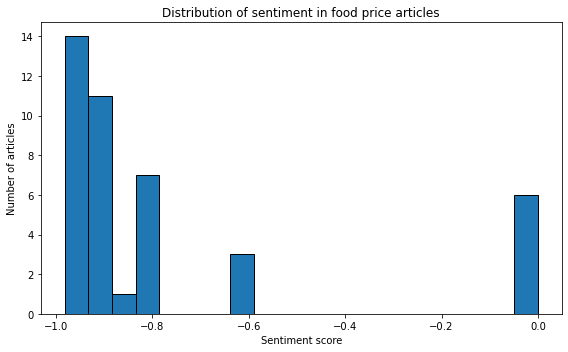

In [92]:
plt.figure(figsize=(8,5))
plt.hist(news_filtered["sentiment"], bins=20, edgecolor="black")

plt.title("Distribution of sentiment in food price articles")
plt.xlabel("Sentiment score")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

### Interpretation


This histogram shows the distribution of sentiment scores for news articles related to food prices and inflation. Most articles have negative sentiment values, indicating that media coverage of food prices is predominantly pessimistic.

This negative tone likely reflects concerns about rising living costs and inflation, which are frequently framed as economic challenges in news reporting.

Only a few articles are close to neutral sentiment, while positive sentiment is nearly absent. This suggests that media coverage tends to emphasize the burdens associated with food price developments rather than positive economic perspectives.

Because the dataset includes only a limited number of filtered articles, the distribution should be interpreted as an indicator of the overall tone of the sample rather than a comprehensive picture of media sentiment.

## 2. Monthly media attention and sentiment on food prices

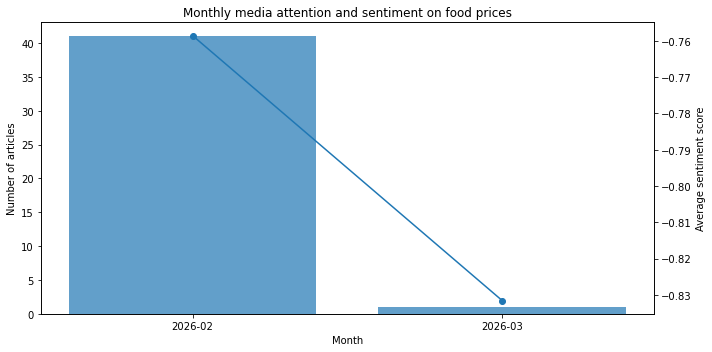

In [93]:
# Aggregate sentiment scores and article counts at the monthly level.
fig, ax1 = plt.subplots(figsize=(10,5))

x =sentiment_monthly["month"].dt.strftime("%Y-%m")

ax1.bar(x, sentiment_monthly["article_count"], alpha=0.7, label="Article count")
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of articles")

ax2 = ax1.twinx()
ax2.plot(x, sentiment_monthly["avg_sentiment"], marker="o", label="Average sentiment")
ax2.set_ylabel("Average sentiment score")

plt.title("Monthly media attention and sentiment on food prices")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Interpretation

The figure compares the monthly number of food price-related news articles with the average sentiment of those articles. Media attention is substantially higher in the first observed month than in the second.

At the same time, average sentiment is negative in both months. This suggests that food price reporting remained critical regardless of the level of media attention.

Because the dataset covers only two months, the figure should be interpreted cautiously. It provides a descriptive comparison rather than strong evidence of a stable relationship between media attention and sentiment.

## 4. Consumer price indices for dairy and butter in Germany

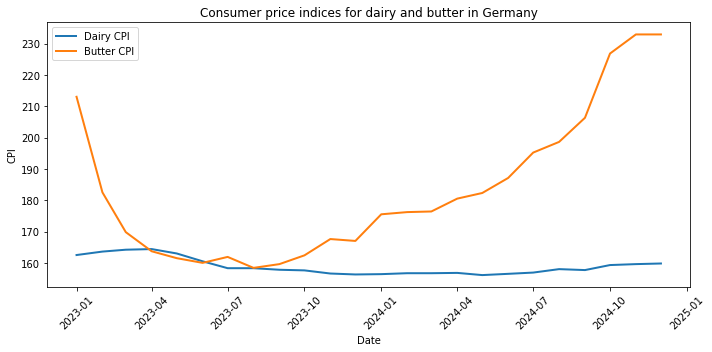

In [94]:
# Plot the consumer price indices for dairy products and butter over time.
plt.figure(figsize=(10,5))

plt.plot(dairy["date"], dairy["dairy_cpi"], label="Dairy CPI", linewidth=2)
plt.plot(butter["date"], butter["butter_cpi"], label="Butter CPI", linewidth=2)

plt.title("Consumer price indices for dairy and butter in Germany")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

The figure compares the consumer price indices for dairy and butter in Germany over the observed period. While the dairy CPI remains relatively stable, the butter CPI shows much stronger fluctuations and a clear upward trend.

This indicates that butter experienced a more pronounced price increase than dairy products overall. In particular, the sharp rise in the butter CPI highlights how strongly individual food categories can be affected by inflation.

These price developments provide important economic context for the broader discussion of food prices and rising living costs in Germany. However, they should not be interpreted as directly synchronized with the news sentiment data, since the datasets cover different time periods.

## 4. Monthly CPI changes for dairy and butter

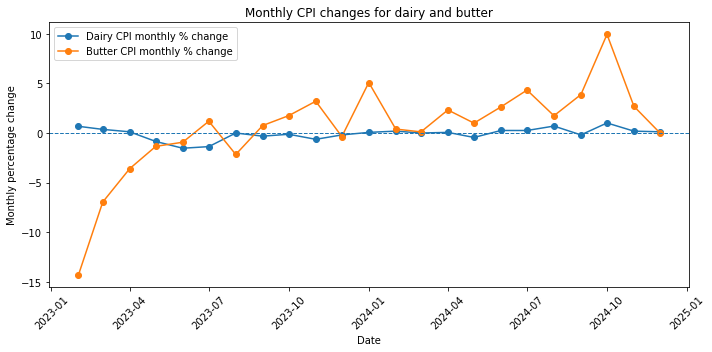

In [95]:
# Plot monthly percentage changes for the dairy and butter CPI series.
dairy_change = dairy.copy()
butter_change = butter.copy()
# Calculate monthly percentage changes for both CPI series.
dairy_change["dairy_pct_change"] = dairy_change["dairy_cpi"].pct_change() * 100
butter_change["butter_pct_change"] = butter_change["butter_cpi"].pct_change() * 100

plt.figure(figsize=(10,5))
plt.plot(dairy_change["date"], dairy_change["dairy_pct_change"], marker="o", label="Dairy CPI monthly % change")
plt.plot(butter_change["date"], butter_change["butter_pct_change"], marker="o", label="Butter CPI monthly % change")

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Monthly CPI changes for dairy and butter")
plt.xlabel("Date")
plt.ylabel("Monthly percentage change")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation

This figure shows the month-to-month percentage changes in the consumer price indices for dairy and butter. In contrast to the CPI level chart, it highlights the speed and volatility of price movements over time.

The results suggest that butter prices changed more strongly from month to month than dairy prices overall. While dairy CPI remained relatively stable, butter CPI showed larger positive and negative movements, indicating greater short-term volatility.

This supports the earlier finding that butter was more strongly affected by food price inflation than dairy products in general.

## Limitations

A key limitation of this analysis is the mismatch in time coverage between the datasets.  
The CPI data covers food price developments in Germany from 2023 to 2024, while the available news data mainly covers early 2026.

Because of this mismatch, the notebook does not test a strict time-synchronized relationship between price movements and media sentiment. Instead, it compares food price developments and media discourse as related but separate indicators.

In addition, the sentiment analysis is based on VADER, which is a general-purpose lexicon-based method and may not fully capture the tone of economic reporting.

## Overall Conclusion

This notebook combines consumer price index data with sentiment analysis of news coverage to explore how food price inflation is reflected in public discourse.

The CPI data shows that dairy products, and especially butter, experienced noticeable price increases during the observed period. The news analysis further indicates that reporting on inflation and food prices was slightly negative on average.

Due to the different time periods covered by the datasets, these findings should not be interpreted as evidence of a direct causal or month-by-month relationship. Instead, the results suggest that food price inflation and critical media coverage are both important parts of the broader public discussion of rising living costs in Germany.